In [2]:
#General packages
from IPython.display import clear_output #import of a single funtcion
import sys #system related packages
import os #better path and file handling
import pickle #saving and loading objects

#Tables, numbers etc
import pandas as pd #tables
import numpy as np #arrays
import scipy #sciency functions
from sklearn import mixture #For gaussian mixture model

#Plotting packages
import matplotlib.pyplot as plt #Main plotting
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import seaborn as sbn #nicer plots

#RNA-seq analysis
import scanpy as sc #Main package for scRNA-seq analysis
import scanpy.external as sce #some more functions for scanpy
import bbknn #batch correction


#Import some custom helper functions for plotting
path_skin_scripts = '/mnt/p/users/Karl/Python/Projects'
sys.path.append(path_skin_scripts)
from Skin_scripts import *

path_skin_scripts = '/mnt/p/users/Karl/Python/Projects/Human_skin_Hao'
sys.path.append(path_skin_scripts)
from Constants import *
#from spatial_functions import *

import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = False
mpl.rcParams['pdf.fonttype'] = 42

import warnings
warnings.simplefilter("ignore")

/opt/miniforge3/envs/karlpy/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/miniforge3/envs/karlpy/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/opt/miniforge3/envs/karlpy/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [3]:
fig_path = '/mnt/p/users/Hao/iHSCA_manuscript/Figure_items/Mapping with Ober-Reynolds/Figures'
path = '/mnt/p/users/Hao/iHSCA_manuscript/Figure_items/Mapping with Ober-Reynolds/v70_H_O'
path

'/mnt/p/users/Hao/iHSCA_manuscript/Figure_items/Mapping with Ober-Reynolds/v70_H_O'

# 1st level

In [4]:
adata = sc.read_h5ad(os.path.join(path, 'adata_all_20260304.h5ad'))
adata

AnnData object with n_obs × n_vars = 492497 × 82285
    obs: 'study_id', 'experiment_id', 'institute', 'author_batch_notes', 'organism', 'organism_ontology_term_id', 'donor_id', 'donor_id_running', 'sex_ontology_term', 'sex_ontology_term_id', 'ethnicity_1', 'ethnicity_2', 'ethnicity_details', 'self_reported_ethnicity_ontology_term_id', 'genotype', 'age_years', 'age_range', 'development_stage_ontology_term', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'disease_status', 'treatment_status', 'smoking_status', 'smoking_history', 'bmi', 'systemic_disorder', 'autoimmune_component', 'menopause_status', 'puperty_status', 'sun_exposure', 'skin_tone', 'skin_care', 'manner_of_death', 'sample_id', 'sample_id_running', 'sample_source', 'sample_collection_method', 'sampled_site_condition', 'anatomical_region_level_1', 'anatomical_region_level_2', 'anatomical_region_level_3', 'anatomical_region', 'tissue_type', 'tissue_free_text', 'tissue_ontology_term', 'tissue_ontolo

In [5]:
adata.obs['RG_to_H'] = adata.obs['RG_to_H'].replace('nan', pd.NA)
adata.obs['QUE_author_cell_type_1'] = adata.obs['QUE_author_cell_type_1'].replace('nan', pd.NA)
adata.obs['QUE_author_cell_type_2'] = adata.obs['QUE_author_cell_type_2'].replace('nan', pd.NA)
adata.obs['QUE_author_cell_type_3'] = adata.obs['QUE_author_cell_type_3'].replace('nan', pd.NA)

## Fig S6c

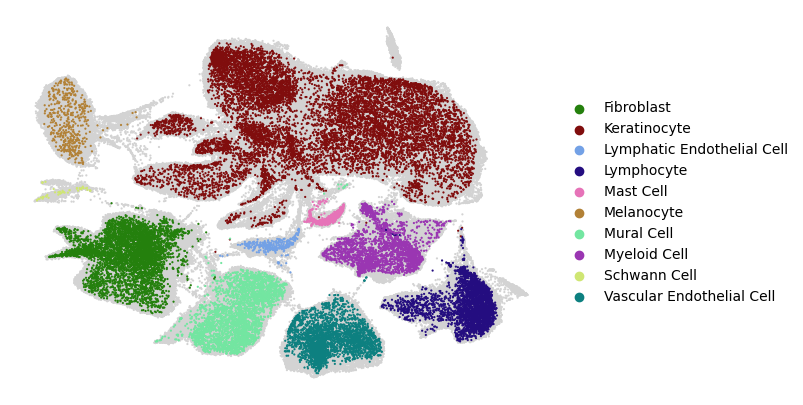

In [21]:
basis = 'integrated_UMAP_L1_PCA_all_EA_k-NN'

fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(adata, basis = basis, color = 'RG_to_H', na_in_legend=False, s = 10, palette = cmap_1st, title = '', frameon = False, show = False, ax = ax)

fig.savefig(os.path.join(fig_path, 'UMAP_1st_RG_to_H.png'), bbox_inches = 'tight', dpi = 1200)

In [29]:
cmap_1st

{'Keratinocyte': (0.5, 0.04999999999999999, 0.04999999999999999),
 'Melanocyte': (0.7, 0.504, 0.21000000000000002),
 'Schwann Cell': (0.8099999999999999, 0.9, 0.45),
 'Fibroblast': (0.14000000000000007, 0.5, 0.04999999999999999),
 'Mural Cell': (0.45, 0.9, 0.6300000000000002),
 'Vascular Endothelial Cell': (0.04999999999999999, 0.5, 0.5),
 'Lymphatic Endothelial Cell': (0.45, 0.6300000000000002, 0.9),
 'Lymphocyte': (0.13999999999999968, 0.04999999999999999, 0.5),
 'Myeloid Cell': (0.6020000000000003, 0.21000000000000002, 0.7),
 'Mast Cell': (0.9, 0.45, 0.7199999999999999)}

In [5]:
cmap_OR = {'Bc': (0.05, 0.25, 0.90),
           'Fb': (0.14000000000000007, 0.5, 0.04999999999999999),
           'Kc': (0.5, 0.04999999999999999, 0.04999999999999999),
           'Le': (0.45, 0.6300000000000002, 0.9),
           'Ma': (0.9, 0.45, 0.7199999999999999),
           'Me': (0.7, 0.504, 0.21000000000000002),
           'Mu': (0.45, 0.9, 0.6300000000000002),
           'My': (0.6020000000000003, 0.21000000000000002, 0.7),
           'Tc': (0.13999999999999968, 0.04999999999999999, 0.5),
           'Ve': (0.04999999999999999, 0.5, 0.5)}

In [59]:
rename_1st = {
    'Bc': 'Plasma cells',
    'Fb': 'Fibroblasts',
    'Kc': 'Keratinocytes',
    'Le': 'Lymphatic',
    'Ma': 'Mast',
    'Me': 'Melanocytes',
    'Mu': 'Muscle/Pericytes',
    'My': 'Myeloid',
    'Tc': 'Lymphoid',
    'Ve': 'Vascular (endothelial)',
}

rename_2nd = {
'rFb1': 'D.Fib',
'rFb2': 'D.Sheath',
'rTc1': 'Tregs',
'rTc2': 'CD4.Tc',
'rTc3': 'CD8.Tc',
'rMy1': 'DCs_1',
'rMy2': 'Macs_1',
'rMy3': 'CLEC9a.DC',
'rMy4': 'M1.macs',
'rMa1': 'Mast',
'rKc1': 'Spinous.Kc_1',
'rKc2': 'Spinous.Kc_2',
'rKc3': 'HF.Kc_1',
'rKc4': 'Basal.Kc_1',
'rKc5': 'Basal.Kc_2',
'rMu1': 'Muscle',
'rMu2': 'Pericytes',
'rVe1': 'Vas.Endo',
'rLe1': 'Lymph.Endo',
'rMe1': 'Melanocytes_1',
'rMe2': 'Melanocytes_2',
'rBc1': 'Plasma'}

rename_3rd = {
'rTc1': 'CD4.Tc_1',
'rTc2': 'CD4.Tc_2',
'rTc3': 'CD8.Tc',
'rTc4': 'Treg',
'rTc5': 'NK',
'rTc6': 'Cyc.Tc',
'rMy1': 'cDC2',
'rMy2': 'M2.macs_1',
'rMy3': 'M2.macs_2',
'rMy4': 'CLEC9a.DC',
'rMy5': 'M1.macs',
'rMy6': 'TCR.macs',
'rMy7': 'TREM2.macs',
'rMy8': 'Plasma.contam',
'rKc1': 'Basal.Kc_1',
'rKc2': 'Spinous.Kc_1',
'rKc3': 'Spinous.Kc_2',
'rKc4': 'Spinous.Kc_3',
'rKc5': 'Infundibulum',
'rKc6': 'Cyc.Kc_1',
'rKc7': 'Inf.Segment',
'rKc8': 'Sebaceous',
'rKc9': 'Isthmus',
'rKc10': 'Eccrine',
'rFb1': 'D.Fib_1',
'rFb2': 'D.Sheath',
'rFb3': 'D.Fib_2',
'rFb4': 'D.Fib_3',
'rFb5': 'D.Fib_4',
'rFb6': 'D.Fib_5',
'rFb7': 'D.Papilla',
'rVe1': 'Vas.Endo_1',
'rVe2': 'Vas.Endo_2',
'rVe3': 'Vas.Endo_3',
'rVe4': 'Vas.Endo_4',
'rVe5': 'Unknown',
'rLe1': 'Lymph.Endo_1',
'rMa1': 'Mast',
'rMu1': 'Muscle',
'rMu2': 'Pericytes',
'rMe1': 'Melanocytes_1',
'rMe2': 'Melanocytes_2',
'rBc1': 'Plasma'
}

In [61]:
adata.obs['QUE_author_cell_type_1_long'] = adata.obs['QUE_author_cell_type_1'].map(rename_1st)
adata.obs['QUE_author_cell_type_2_long'] = adata.obs['QUE_author_cell_type_2'].map(rename_2nd)
adata.obs['QUE_author_cell_type_2_long'] = adata.obs['QUE_author_cell_type_2'].map(rename_3rd)

In [68]:
cmap_OR = {'Bc': (0.05, 0.25, 0.90),
           'Fb': '#5c2c7c',
           'Kc': '#60ab5c',
           'Le': '#fde306',
           'Ma': '#c06cac',
           'Me': '#7c1417',
           'Mu': '#a04a96',
           'My': '#5f7ca6',
           'Tc': '#d42125',
           'Ve': '#f47d29',
          }
cmap_OR = {cl: cmap_OR[cl_short] for cl_short, cl in rename_1st.items()}
cmap_OR

{'Plasma cells': (0.05, 0.25, 0.9),
 'Fibroblasts': '#5c2c7c',
 'Keratinocytes': '#60ab5c',
 'Lymphatic': '#fde306',
 'Mast': '#c06cac',
 'Melanocytes': '#7c1417',
 'Muscle/Pericytes': '#a04a96',
 'Myeloid': '#5f7ca6',
 'Lymphoid': '#d42125',
 'Vascular (endothelial)': '#f47d29'}

## Fig S6b

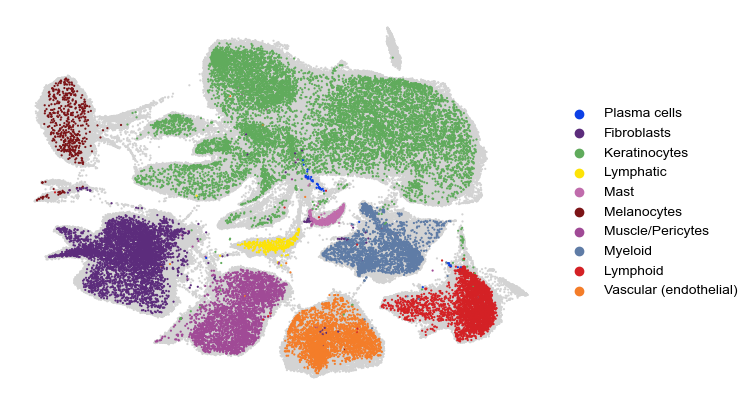

In [70]:
basis = 'integrated_UMAP_L1_PCA_all_EA_k-NN'

fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(adata, basis = basis, color = 'QUE_author_cell_type_1_long', na_in_legend=False, s = 10, title = '', frameon = False, show = False, ax = ax, palette = cmap_OR)

for coll in ax.collections:
    if isinstance(coll, mpl.collections.PathCollection):
        coll.set_rasterized(True)
            
fig.savefig(os.path.join(fig_path, 'UMAP_1st_RG_clusters_v3.pdf'), bbox_inches = 'tight', dpi = 600)

## Fig S6d

[None]

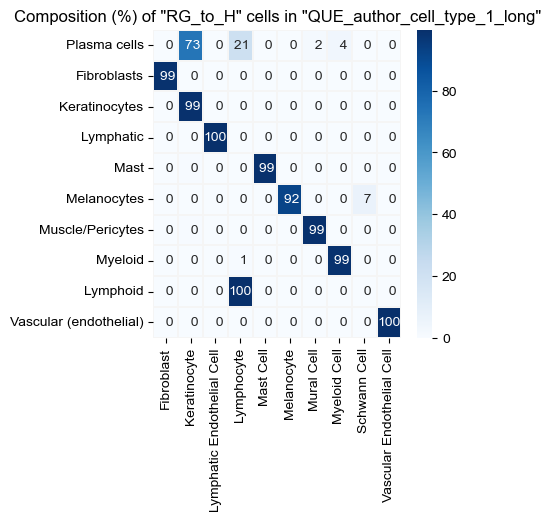

In [71]:
fig, ax = plt.subplots(figsize = (4, 4))
plot_group_composition_heatmap(adata[adata.obs['study_id'] == 'Reynolds_Greenleaf_NatureGenetics_2023'].obs, groupby_name='QUE_author_cell_type_1_long', count_group_name='RG_to_H', cmap = 'Blues', ax = ax, lw = 0.05, linecolor = 'whitesmoke')
ax.set_xlabel('')
ax.set_ylabel('')
clear_output()

[fig.savefig(os.path.join(fig_path, f'Confusion_matrix_knn_RG_to_H_v2.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['pdf']]

<Axes: xlabel='integrated_UMAP_L1_PCA_all_EA_k-NN1', ylabel='integrated_UMAP_L1_PCA_all_EA_k-NN2'>

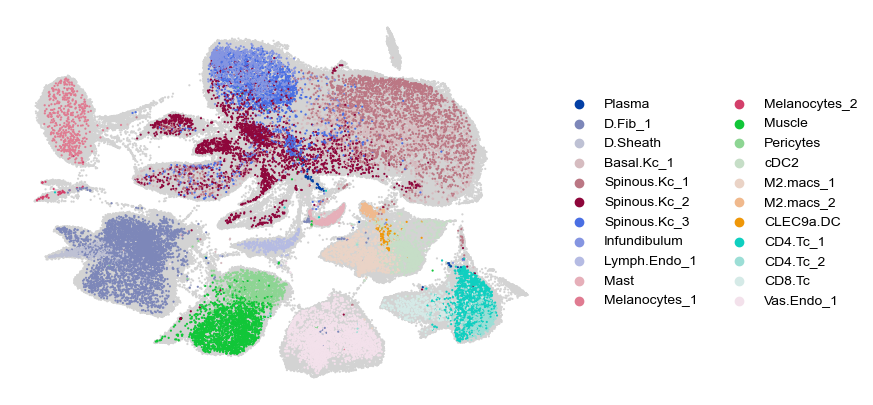

In [72]:
basis = 'integrated_UMAP_L1_PCA_all_EA_k-NN'

fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(adata, basis = basis, color = 'QUE_author_cell_type_2_long', na_in_legend=False, s = 10, title = '', frameon = False, show = False, ax = ax)

#fig.savefig(os.path.join(fig_path, 'UMAP_1st_RG_to_H.png'), bbox_inches = 'tight', dpi = 1200)

<Axes: xlabel='integrated_UMAP_L1_PCA_all_EA_k-NN1', ylabel='integrated_UMAP_L1_PCA_all_EA_k-NN2'>

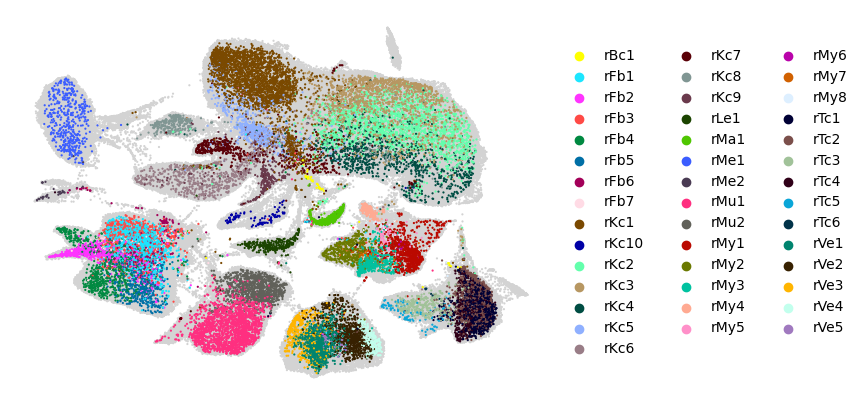

In [30]:
basis = 'integrated_UMAP_L1_PCA_all_EA_k-NN'

fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(adata, basis = basis, color = 'QUE_author_cell_type_3', na_in_legend=False, s = 10, title = '', frameon = False, show = False, ax = ax)

#fig.savefig(os.path.join(fig_path, 'UMAP_1st_RG_to_H.png'), bbox_inches = 'tight', dpi = 1200)

# Level 2

## KC

In [7]:
kc_data = sc.read_h5ad(os.path.join(path, 'Keratinocyte', 'adata_KC.h5ad'), backed = 'r')
kc_data

AnnData object with n_obs × n_vars = 262860 × 82285 backed at '/mnt/p/users/Hao/iHSCA_manuscript/Figure_items/Mapping with Ober-Reynolds/v70_H_O/Keratinocyte/adata_KC.h5ad'
    obs: 'study_id', 'experiment_id', 'institute', 'author_batch_notes', 'organism', 'organism_ontology_term_id', 'donor_id', 'donor_id_running', 'sex_ontology_term', 'sex_ontology_term_id', 'ethnicity_1', 'ethnicity_2', 'ethnicity_details', 'self_reported_ethnicity_ontology_term_id', 'genotype', 'age_years', 'age_range', 'development_stage_ontology_term', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'disease_status', 'treatment_status', 'smoking_status', 'smoking_history', 'bmi', 'systemic_disorder', 'autoimmune_component', 'menopause_status', 'puperty_status', 'sun_exposure', 'skin_tone', 'skin_care', 'manner_of_death', 'sample_id', 'sample_id_running', 'sample_source', 'sample_collection_method', 'sampled_site_condition', 'anatomical_region_level_1', 'anatomical_region_level_2', 'a

In [8]:
kc_data.obs['Q_to_R'] = kc_data.obs['Q_to_R'].replace('nan', pd.NA).astype(object)
kc_data.obs['QUE_author_cell_type_1'] = kc_data.obs['QUE_author_cell_type_1'].replace('nan', pd.NA)
kc_data.obs['QUE_author_cell_type_2'] = kc_data.obs['QUE_author_cell_type_2'].replace('nan', pd.NA)
kc_data.obs['QUE_author_cell_type_3'] = kc_data.obs['QUE_author_cell_type_3'].replace('nan', pd.NA)

In [88]:
kc_data.obs['QUE_author_cell_type_1_long'] = kc_data.obs['QUE_author_cell_type_1'].map(rename_1st)
kc_data.obs['QUE_author_cell_type_2_long'] = kc_data.obs['QUE_author_cell_type_2'].map(rename_2nd)
kc_data.obs['QUE_author_cell_type_3_long'] = kc_data.obs['QUE_author_cell_type_3'].map(rename_3rd)
kc_data.obs['QUE_author_cell_type_3_long'] = kc_data.obs['QUE_author_cell_type_3_long'].replace('Spinous.Kc_3', 'Inf.Segment_2').replace('Inf.Segment', 'Inf.Segment_1').replace('Cyc.Kc_1', 'Matrix') #Was labelled as Spinous.Kc_3, but on the plot it liiks like this should be infu differentiated cluster

In [9]:
cmap_kc = {cl: kc_colors[cl.split(':')[0].split(' - ')[-1]] for cl in kc_data.obs['Q_to_R'].unique() if isinstance(cl, str)}

### Fig 6d

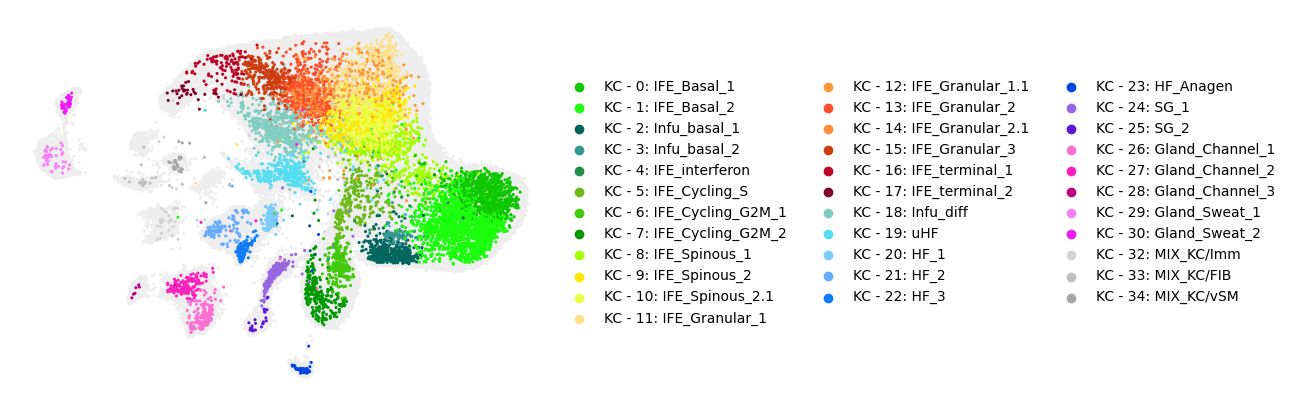

In [92]:
basis = 'integrated_UMAP_L2_PCA_KC_EA_k-NN'

fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(kc_data, basis = basis, color = 'Q_to_R', na_in_legend=False, s = 20, palette = cmap_kc, title = '', frameon = False, show = False, ax = ax, na_color='#eeeeee')

fig.savefig(os.path.join(fig_path, 'UMAP_2nd_KC_RG_to_H.png'), bbox_inches = 'tight', dpi = 1200)

In [89]:
kc_data.obs['QUE_author_cell_type_3_long'] = pd.Categorical(kc_data.obs['QUE_author_cell_type_3_long'], categories=['Basal.Kc_1', 'Spinous.Kc_2', 'Spinous.Kc_1', 'Infundibulum', 'Inf.Segment_1', 'Inf.Segment_2', 'Sebaceous', 'Isthmus', 'Matrix', 'Eccrine'], ordered = True)

In [91]:
cmap_OR_KC = {'Basal.Kc_1': '#d42027',
 'Spinous.Kc_1': '#252e6a',
 'Spinous.Kc_2': '#218a43',
 'Inf.Segment_2': '#89c65f', #Was labelled as Spinous.Kc_3, but on the plot it liiks like this should be infu differentiated cluster
 'Infundibulum': '#f47c29',
 'Matrix': '#f27a7b', #Was labelled as Cyc.Kc_1
 'Inf.Segment_1': '#889ed0',
 'Sebaceous': '#c16bab',
 'Isthmus': '#d7a866',
 'Eccrine': '#8ed5e4'}

#cmap_OR = {cl: cmap_OR_KC[cl] for cl_short, cl in rename_2nd.items() if cl in cmap_OR_KC.keys()}

### Fig 6c

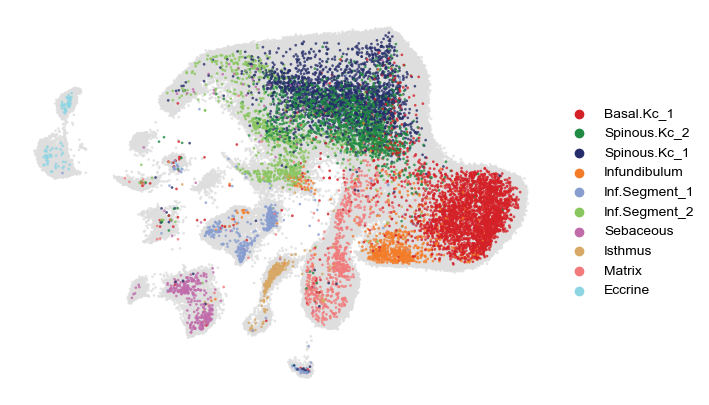

In [105]:
basis = 'integrated_UMAP_L2_PCA_KC_EA_k-NN'

fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(kc_data, basis = basis, color = 'QUE_author_cell_type_3_long', na_in_legend=False, s = 15, title = '', frameon = False, show = False, ax = ax, na_color='#dedede', alpha = 0.8, palette = cmap_OR_KC)

for coll in ax.collections:
    if isinstance(coll, mpl.collections.PathCollection):
        coll.set_rasterized(True)
        
fig.savefig(os.path.join(fig_path, 'UMAP_2nd_KC_RG_clusters_v2.pdf'), bbox_inches = 'tight', dpi = 600)

### Fig 6e

[None]

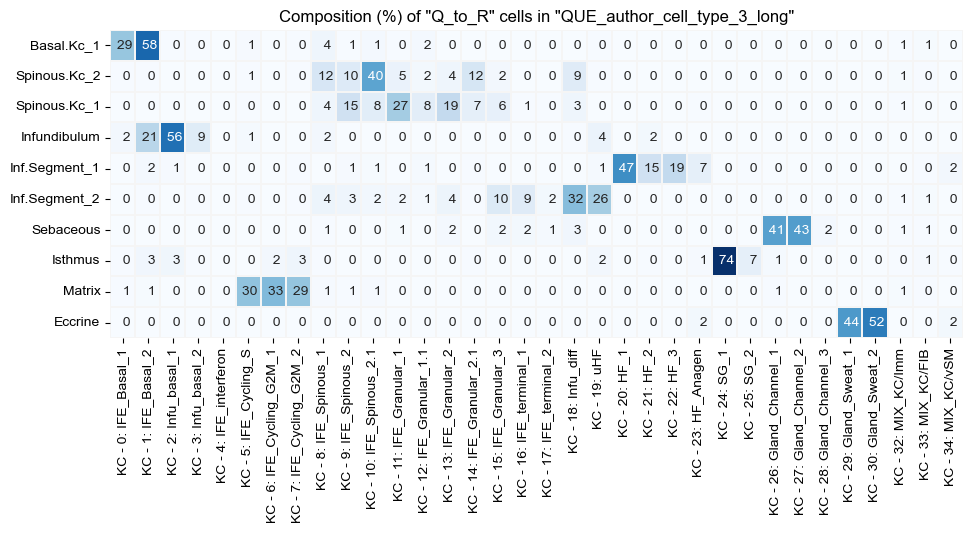

In [95]:
fig, ax = plt.subplots(figsize = (11, 4))
plot_group_composition_heatmap(kc_data[kc_data.obs['study_id'] == 'Reynolds_Greenleaf_NatureGenetics_2023'].obs, groupby_name='QUE_author_cell_type_3_long', count_group_name='Q_to_R', cmap = 'Blues', ax = ax, lw = 0.05, linecolor = 'whitesmoke')
ax.set_xlabel('')
ax.set_ylabel('')
clear_output()
ax.collections[0].colorbar.remove()
[fig.savefig(os.path.join(fig_path, f'Confusion_matrix_2nd_KC_knn_RG_to_H_v2.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['pdf']]

## VEC

In [48]:
os.listdir(os.path.join(path, 'LymphaticEndothelialCell'))

['group_composition_heatmap_adata_LEC.pdf',
 'figures',
 'knn_result.rds',
 'adata_LEC.h5ad']

In [49]:
lec_data = sc.read_h5ad(os.path.join(path, 'LymphaticEndothelialCell', 'adata_LEC.h5ad'))
lec_data

AnnData object with n_obs × n_vars = 5761 × 82285
    obs: 'study_id', 'experiment_id', 'institute', 'author_batch_notes', 'organism', 'organism_ontology_term_id', 'donor_id', 'donor_id_running', 'sex_ontology_term', 'sex_ontology_term_id', 'ethnicity_1', 'ethnicity_2', 'ethnicity_details', 'self_reported_ethnicity_ontology_term_id', 'genotype', 'age_years', 'age_range', 'development_stage_ontology_term', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'disease_status', 'treatment_status', 'smoking_status', 'smoking_history', 'bmi', 'systemic_disorder', 'autoimmune_component', 'menopause_status', 'puperty_status', 'sun_exposure', 'skin_tone', 'skin_care', 'manner_of_death', 'sample_id', 'sample_id_running', 'sample_source', 'sample_collection_method', 'sampled_site_condition', 'anatomical_region_level_1', 'anatomical_region_level_2', 'anatomical_region_level_3', 'anatomical_region', 'tissue_type', 'tissue_free_text', 'tissue_ontology_term', 'tissue_ontology

In [51]:
lec_data.obs['QUE_author_cell_type_3'].value_counts()

QUE_author_cell_type_3
nan     5452
rLe1     309
Name: count, dtype: int64

In [11]:
vec_data = sc.read_h5ad(os.path.join(path, 'VascularEndothelialCell', 'adata_VEC.h5ad'))
vec_data

AnnData object with n_obs × n_vars = 29584 × 82285
    obs: 'study_id', 'experiment_id', 'institute', 'author_batch_notes', 'organism', 'organism_ontology_term_id', 'donor_id', 'donor_id_running', 'sex_ontology_term', 'sex_ontology_term_id', 'ethnicity_1', 'ethnicity_2', 'ethnicity_details', 'self_reported_ethnicity_ontology_term_id', 'genotype', 'age_years', 'age_range', 'development_stage_ontology_term', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'disease_status', 'treatment_status', 'smoking_status', 'smoking_history', 'bmi', 'systemic_disorder', 'autoimmune_component', 'menopause_status', 'puperty_status', 'sun_exposure', 'skin_tone', 'skin_care', 'manner_of_death', 'sample_id', 'sample_id_running', 'sample_source', 'sample_collection_method', 'sampled_site_condition', 'anatomical_region_level_1', 'anatomical_region_level_2', 'anatomical_region_level_3', 'anatomical_region', 'tissue_type', 'tissue_free_text', 'tissue_ontology_term', 'tissue_ontolog

In [12]:
vec_data.obs['Q_to_R'] = vec_data.obs['Q_to_R'].replace('nan', pd.NA).astype(object)
vec_data.obs['QUE_author_cell_type_1'] = vec_data.obs['QUE_author_cell_type_1'].replace('nan', pd.NA)
vec_data.obs['QUE_author_cell_type_2'] = vec_data.obs['QUE_author_cell_type_2'].replace('nan', pd.NA)
vec_data.obs['QUE_author_cell_type_3'] = vec_data.obs['QUE_author_cell_type_3'].replace('nan', pd.NA)

In [100]:
vec_data.obs['QUE_author_cell_type_1_long'] = vec_data.obs['QUE_author_cell_type_1'].map(rename_1st)
vec_data.obs['QUE_author_cell_type_2_long'] = vec_data.obs['QUE_author_cell_type_2'].map(rename_2nd)
vec_data.obs['QUE_author_cell_type_3_long'] = vec_data.obs['QUE_author_cell_type_3'].map(rename_3rd)
#vec_data.obs['QUE_author_cell_type_3_long'] = vec_data.obs['QUE_author_cell_type_3_long']

In [97]:
cmap_OR_vec = {
    'Vas.Endo_1': '#df0001',
    'Vas.Endo_2': '#020f92',
    'Vas.Endo_3': '#23b900',
    'Vas.Endo_4': '#ff5c08',
    'Unknown': '#f5f46d'}

In [13]:
cmap_vec = {cl: vec_cmap[cl.split(':')[0].split(' - ')[-1]] for cl in vec_data.obs['Q_to_R'].unique() if isinstance(cl, str)}

In [14]:
cmap_vec['VEC - 3: MIX(MUR/FIB)'] = (0.6, 0.6, 0.6)

### Fig 6h

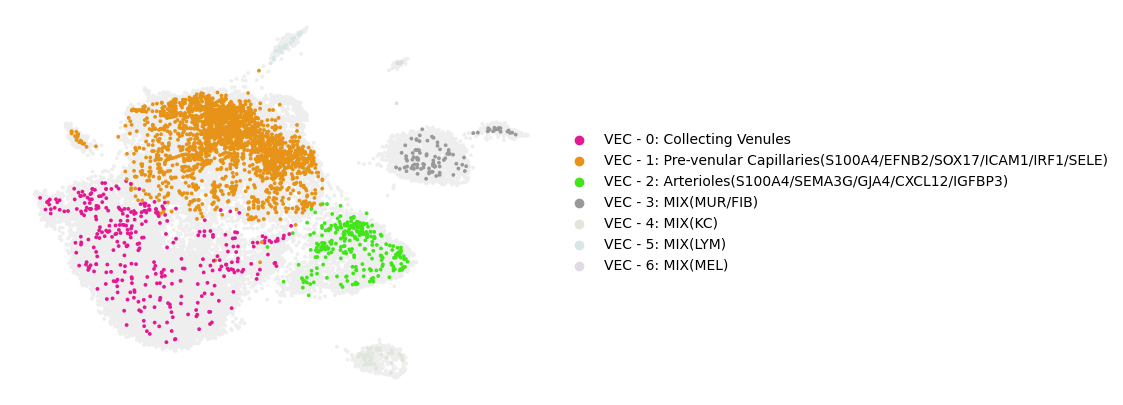

In [144]:
basis = 'integrated_UMAP_L2_PCA_VEC_EA_k-NN'

fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(vec_data, basis = basis, color = 'Q_to_R', na_in_legend=False, s = 30, palette = cmap_vec, title = '', frameon = False, show = False, ax = ax, na_color='#eeeeee')

fig.savefig(os.path.join(fig_path, 'UMAP_2nd_VEC_RG_to_H.png'), bbox_inches = 'tight', dpi = 1200)

### Fig 6g

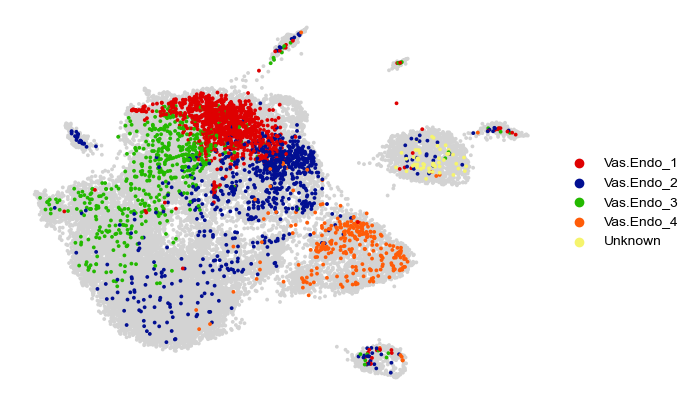

In [104]:
basis = 'integrated_UMAP_L2_PCA_VEC_EA_k-NN'

fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(vec_data, basis = basis, color = 'QUE_author_cell_type_3_long', na_in_legend=False, s = 30, title = '', frameon = False, show = False, ax = ax, palette = cmap_OR_vec)

for coll in ax.collections:
    if isinstance(coll, mpl.collections.PathCollection):
        coll.set_rasterized(True)
        
fig.savefig(os.path.join(fig_path, 'UMAP_2nd_VEC_clusters_v2.pdf'), bbox_inches = 'tight', dpi = 1200)

### Fig 6i

In [145]:
vec_data.obs['QUE_author_cell_type_3'] = pd.Categorical(vec_data.obs['QUE_author_cell_type_3'], categories=natsorted(vec_data.obs['QUE_author_cell_type_3'].cat.categories), ordered=True)

[None]

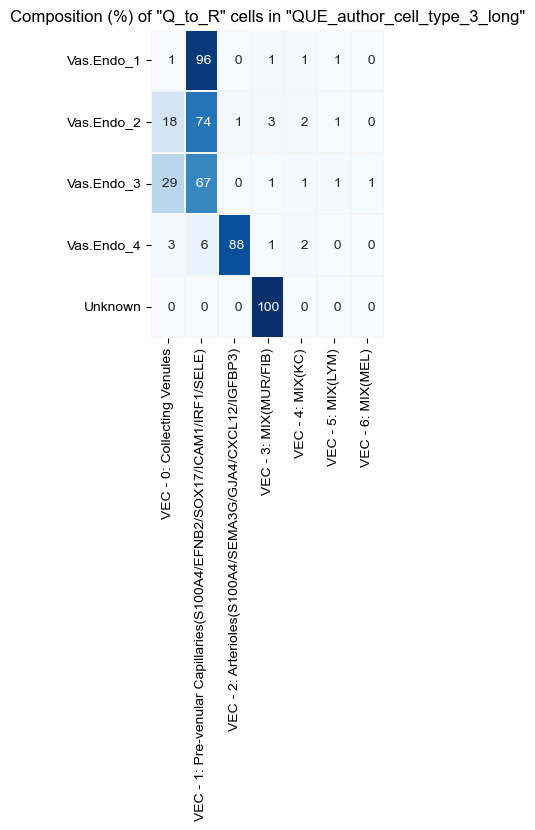

In [103]:
fig, ax = plt.subplots(figsize = (3, 4))
plot_group_composition_heatmap(vec_data[vec_data.obs['study_id'] == 'Reynolds_Greenleaf_NatureGenetics_2023'].obs, groupby_name='QUE_author_cell_type_3_long', count_group_name='Q_to_R', cmap = 'Blues', ax = ax, lw = 0.05, linecolor = 'whitesmoke')
ax.set_xlabel('')
ax.set_ylabel('')
clear_output()
ax.collections[0].colorbar.remove()
[fig.savefig(os.path.join(fig_path, f'Confusion_matrix_2nd_VEC_knn_RG_to_H_v2.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['pdf']]

In [180]:
vec_data.obs['integrated_annotation_L2_shorter'] = vec_data.obs['integrated_annotation_L2_shorter'].replace('nan', pd.NA).astype(object)
vec_data.obs['integrated_annotation_L2'] = vec_data.obs['integrated_annotation_L2'].replace('nan', pd.NA).astype(object)


In [181]:
vec_data.obs['integrated_annotation_L2']

SS3E_Human_Skin_20K___AACATAGCCTAGTGTCGAGG                                                 VEC - 0: Collecting Venules
SS3E_Human_Skin_20K___AACATAGCCTCCAACGGTGA                           VEC - 1: Pre-venular Capillaries(S100A4/EFNB2/...
SS3E_Human_Skin_20K___AACATAGCCTTGAAGGTGAA                           VEC - 1: Pre-venular Capillaries(S100A4/EFNB2/...
SS3E_Human_Skin_20K___AACGGACTCGAGAACAGTGA                                                 VEC - 0: Collecting Venules
SS3E_Human_Skin_20K___AACTACCACTTGCACAAGTA                           VEC - 1: Pre-venular Capillaries(S100A4/EFNB2/...
                                                                                           ...                        
Reynolds_Greenleaf_NatureGenetics_2023___C_SD3_TTTGACTCACACAGAG-1                                                  NaN
Reynolds_Greenleaf_NatureGenetics_2023___C_SD3_TTTGGAGGTCCAGCAC-1                                                  NaN
Reynolds_Greenleaf_NatureGenetics_2023___C_SD3_T

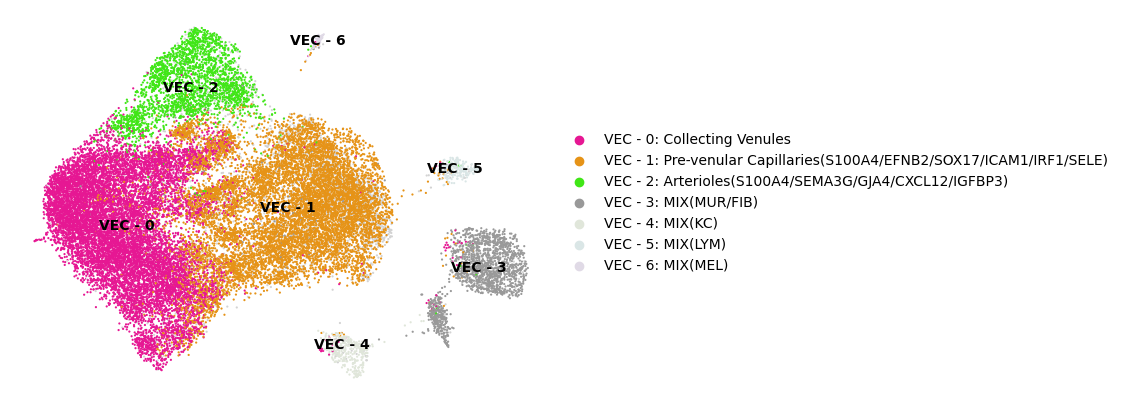

In [190]:
basis = 'UMAP_VEC'

fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(vec_data, basis = basis, color = 'integrated_annotation_L2', na_in_legend=False, s = 10, title = '', frameon = False, show = False, ax = ax, palette = cmap_vec)
sc.pl.embedding(vec_data, basis = basis, color = 'integrated_annotation_L2_shorter', na_in_legend=False, s = 0, title = '', frameon = False, show = False, ax = ax, legend_loc = 'on data')

fig.savefig(os.path.join(fig_path, 'UMAP_2nd_VEC_RG_integration_HSCA_clusters.png'), bbox_inches = 'tight', dpi = 1200)

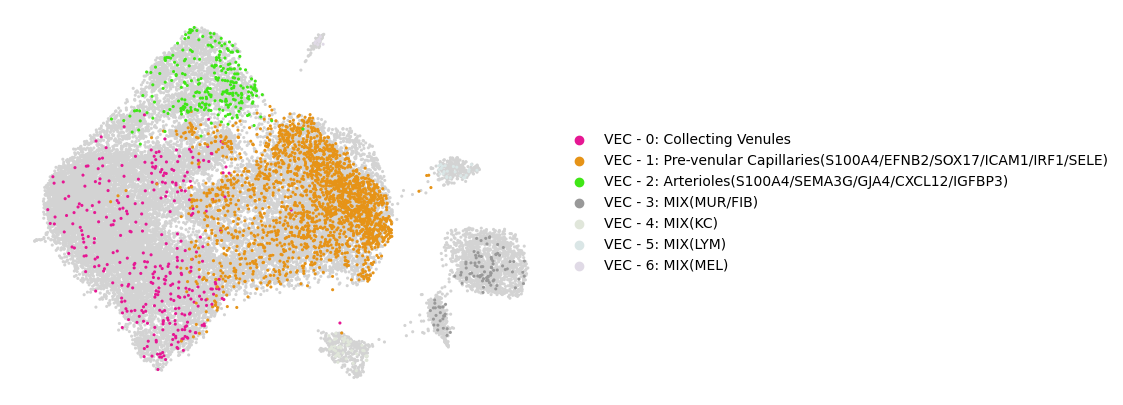

In [193]:
basis = 'UMAP_VEC'

fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(vec_data, basis = basis, color = 'Q_to_R', na_in_legend=False, s = 20, title = '', frameon = False, show = False, ax = ax, palette = cmap_vec)
#sc.pl.embedding(vec_data, basis = basis, color = 'integrated_annotation_L2_shorter', na_in_legend=False, s = 0, title = '', frameon = False, show = False, ax = ax, legend_loc = 'on data')

fig.savefig(os.path.join(fig_path, 'UMAP_2nd_VEC_RG_integration_RG_to_H.png'), bbox_inches = 'tight', dpi = 1200)

### Fig S6h

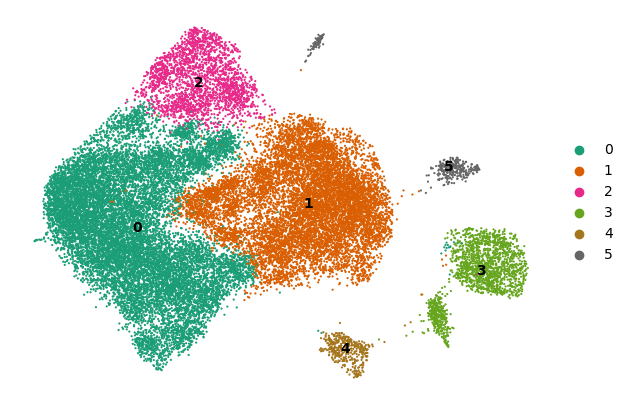

In [212]:
basis = 'UMAP_VEC'
cluster = 'PCA_VEC_leiden_VEC_010'

fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(vec_data, basis = basis, color = cluster, na_in_legend=False, s = 10, title = '', frameon = False, show = False, ax = ax, palette = 'Dark2')
sc.pl.embedding(vec_data, basis = basis, color = cluster, na_in_legend=False, s = 0, title = '', frameon = False, show = False, ax = ax, legend_loc = 'on data')

fig.savefig(os.path.join(fig_path, 'UMAP_2nd_VEC_RG_integration_new_leiden.png'), bbox_inches = 'tight', dpi = 1200)

In [204]:
vec_data.obs['Source'] = np.where(vec_data.obs['study_id']=='Reynolds_Greenleaf_NatureGenetics_2023', 'Ober-Reynolds', 'iHSCA')

[None]

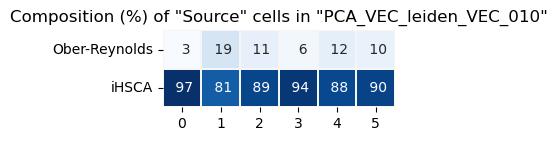

In [218]:
fig, ax = plt.subplots(figsize = (3, 1))
plot_group_composition_heatmap(vec_data.obs, groupby_name='PCA_VEC_leiden_VEC_010', count_group_name='Source', cmap = 'Blues', ax = ax, fmt = '3.0f', transpose = True, lw = 0.05, linecolor = 'whitesmoke')
ax.set_xlabel('')
ax.set_ylabel('')
clear_output()
ax.collections[0].colorbar.remove()

[fig.savefig(os.path.join(fig_path, f'Confusion_matrix_2nd_VEC_integration_leiden.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['pdf']]